In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import astropy
from astropy.table import Table
import seaborn as sns

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE cataloga
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [3]:
from astropy.io import fits
with fits.open('../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

In [4]:
twoprocess_df = fits_to_pandas("../data/astroNN_2proc_crossmatch.fits", hdu=2)
astronn_df = fits_to_pandas("../data/astroNN_2proc_crossmatch.fits", hdu=1)
adrian_df = fits_to_pandas("../data/allStar-dr17-synspec_rev1-GaiaDR3-EDR3_STARHORSE_v2-MilkyWayPotential2022-staeckel.fits")
#astronn_df['MG_FE'] = astronn_df['MG_H'] - astronn_df['FE_H']
#twoprocess_df['A_CC/A_IA'] = twoprocess_df['A_CC']/twoprocess_df['A_IA']
#twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] > 0]
#twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] < 10]

data = (
    adrian_df
    .merge(twoprocess_df, on="APOGEE_ID", how="inner")
    .merge(astronn_df, on="APOGEE_ID", how="inner")
)

data = data.dropna()

data['A_CC/A_IA'] = data['A_CC']/data['A_IA']
data['A_IA/A_CC'] = data['A_IA']/data['A_CC']


data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']


data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']


data = data[data['A_CC/A_IA'] > 0]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "red"
data_low_alpha['color'] = "blue"

#merged = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)
merged = data_low_alpha

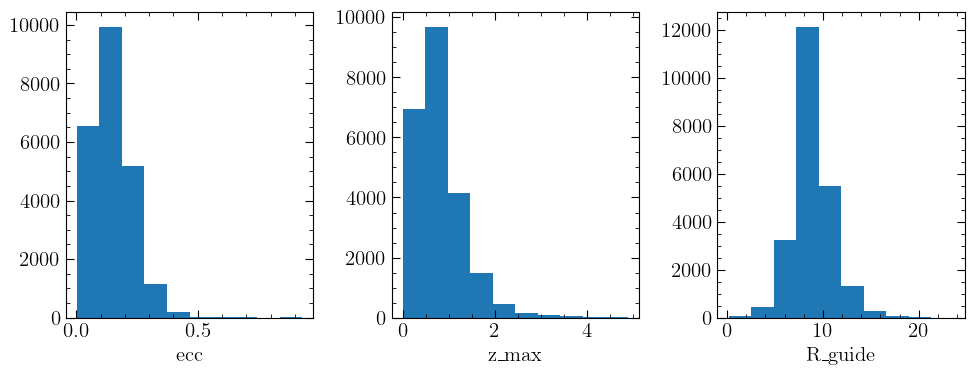

In [5]:
plt.figure(figsize=(10,4))

merged = merged[merged['z_max'] < 5]

plt.subplot(1,3,1)
plt.hist(merged['ecc'])
plt.xlabel('ecc')
mean_ecc = np.mean(merged['ecc'])
std_ecc = np.std(merged['ecc'])



plt.subplot(1,3,2)
plt.hist(merged['z_max'])
plt.xlabel("z_max")
mean_zmax = np.mean(merged['z_max'])
std_zmax = np.std(merged['z_max'])


plt.subplot(1,3,3)
plt.hist(merged['R_guide'])
plt.xlabel("R_guide")
mean_rguide = np.mean(merged['R_guide'])
std_rguide = np.std(merged['R_guide'])



plt.tight_layout()

In [18]:
bin_edges = np.arange(0.5, 12.5, 1)  # 0,1,2,...,10
bin_edges

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5])

In [42]:
merged['R_guide_bin'] = pd.cut(merged['R_guide'], bins=bin_edges, right=False, labels=False)
merged = merged[merged['ecc'] < 0.2]
bin_6 = merged[merged['R_guide_bin'] == 6]
bin_7 = merged[merged['R_guide_bin'] == 7]
bin_8 = merged[merged['R_guide_bin'] == 8]
bin_9 = merged[merged['R_guide_bin'] == 9]

bin_r_g = bin_7

mask_1_zmax = (bin_r_g['z_max'] < 0.5) & (bin_r_g['z_max'] > 0)
mask_2_zmax = (bin_r_g['z_max'] > 0.50) & (bin_r_g['z_max'] < 1)
mask_3_zmax = (bin_r_g['z_max'] > 1) & (bin_r_g['z_max'] < 1.5)

bin_plot = bin_r_g[mask_1_zmax]

#Data to work with: ecc < 0.2, 7 < R_guide < 8, 0 < z_max < 0.5 
#We name this df

df = bin_7

In [43]:
z_bin_edges = np.arange(0, 2.25, 0.25)
z_bin_centers = 0.5 * (z_bin_edges[:-1] + z_bin_edges[1:])
df['zmax_bin'] = pd.cut(df['z_max'], bins=z_bin_edges, right=False, labels=False)

medians_fe_mg = []
means_fe_mg = []
mads_fe_mg = []
stds_fe_mg = []

medians_as = []
means_as = []
mads_as = []
stds_as = []


for i in range(len(z_bin_centers)):
    bin_df = df[df['zmax_bin'] == i]

    medians_fe_mg.append(np.median(bin_df['FE_MG']))
    means_fe_mg.append(np.mean(bin_df['FE_MG']))

    mads_fe_mg.append(np.median(np.abs(bin_df['FE_MG'] - np.median(bin_df['FE_MG']))))
    stds_fe_mg.append(bin_df['FE_MG'].std())

    medians_as.append(np.median(bin_df['A_IA/A_CC']))
    means_as.append(np.mean(bin_df['A_IA/A_CC']))

    mads_as.append(np.median(np.abs(bin_df['A_IA/A_CC'] - np.median(bin_df['A_IA/A_CC']))))
    stds_as.append(bin_df['A_IA/A_CC'].std())

medians_fe_mg = np.array(medians_fe_mg)
means_fe_mg = np.array(means_fe_mg)
mads_fe_mg = np.array(mads_fe_mg)
stds_fe_mg = np.array(stds_fe_mg)

medians_as = np.array(medians_as)
means_as = np.array(means_as)
mads_as = np.array(mads_as)
stds_as = np.array(stds_as)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_89743/2672386293.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['zmax_bin'] = pd.cut(df['z_max'], bins=z_bin_edges, right=False, labels=False)


In [44]:
from scipy.interpolate import CubicSpline

mad_spline_fe_mg = CubicSpline(z_bin_centers, mads_fe_mg)
std_spline_fe_mg = CubicSpline(z_bin_centers, stds_fe_mg)

mad_spline_as = CubicSpline(z_bin_centers, mads_as)
std_spline_as = CubicSpline(z_bin_centers, stds_as)

In [45]:
# FE/MG
median_spline_fe_mg = CubicSpline(z_bin_centers, medians_fe_mg)
# First derivative dY/dz_max
dmedian_dz_fe_mg = median_spline_fe_mg.derivative()

z_fine = np.linspace(z_bin_centers.min(), z_bin_centers.max(), 500)
#z_fine = z_bin_centers

d_fe_mg_dz = dmedian_dz_fe_mg(z_fine)
mad_vals_fe_mg = mad_spline_fe_mg(z_fine)

normalized_gradient_fe_mg = np.abs(d_fe_mg_dz / mad_vals_fe_mg)


# AIA_ACC
median_spline_as = CubicSpline(z_bin_centers, medians_as)

# First derivative dY/dz_max
dmedian_dz_as = median_spline_as.derivative()

d_as_dz = dmedian_dz_as(z_fine)
mad_vals_as = mad_spline_as(z_fine)

normalized_gradient_as = np.abs(d_as_dz / mad_vals_as)

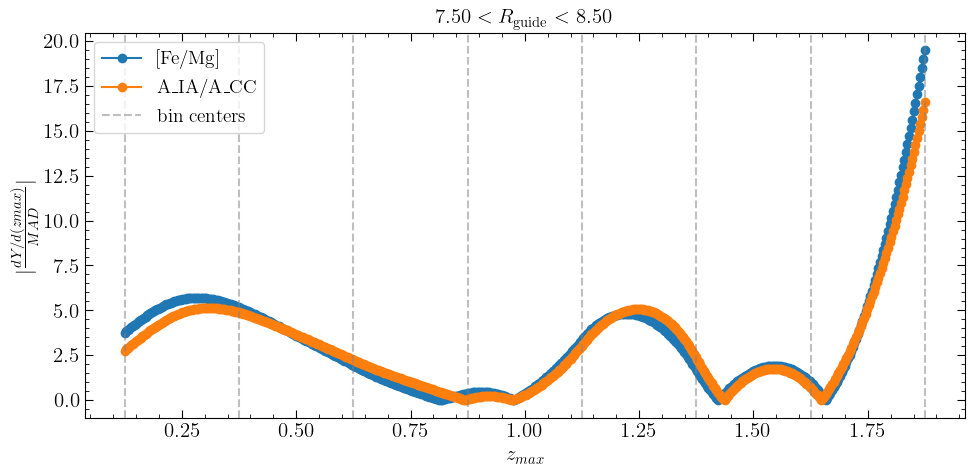

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(z_fine, normalized_gradient_fe_mg, label='[Fe/Mg]', marker='o' )
plt.plot(z_fine, normalized_gradient_as, label='A_IA/A_CC', marker='o')

plt.axvline(z_bin_centers[0], alpha = 0.5, linestyle='--', color = 'gray', label = 'bin centers')
for i in range(1, len(z_bin_centers)):
    plt.axvline(z_bin_centers[i], alpha = 0.5, linestyle='--', color = 'gray')


plt.xlabel(r'$z_{max}$')
plt.ylabel(r'$|\frac{dY/d(zmax)}{MAD}|$')
plt.legend()
Rmin = df['R_guide'].min()
Rmax = df['R_guide'].max()

plt.title(rf"${Rmin:.2f} < R_{{\rm guide}} < {Rmax:.2f}$")

plt.tight_layout()
plt.show()

In [36]:
for i in range(len(z_bin_centers)):
    print(len(df[df['zmax_bin'] == i]))

448
923
1195
1030
499
285
123
44


# 2D Plots

In [13]:
df['zmax_bin']

35        2.0
70        2.0
84        5.0
85        5.0
86        5.0
         ... 
338064    6.0
338172    0.0
338497    2.0
338651    2.0
339527    6.0
Name: zmax_bin, Length: 4894, dtype: float64

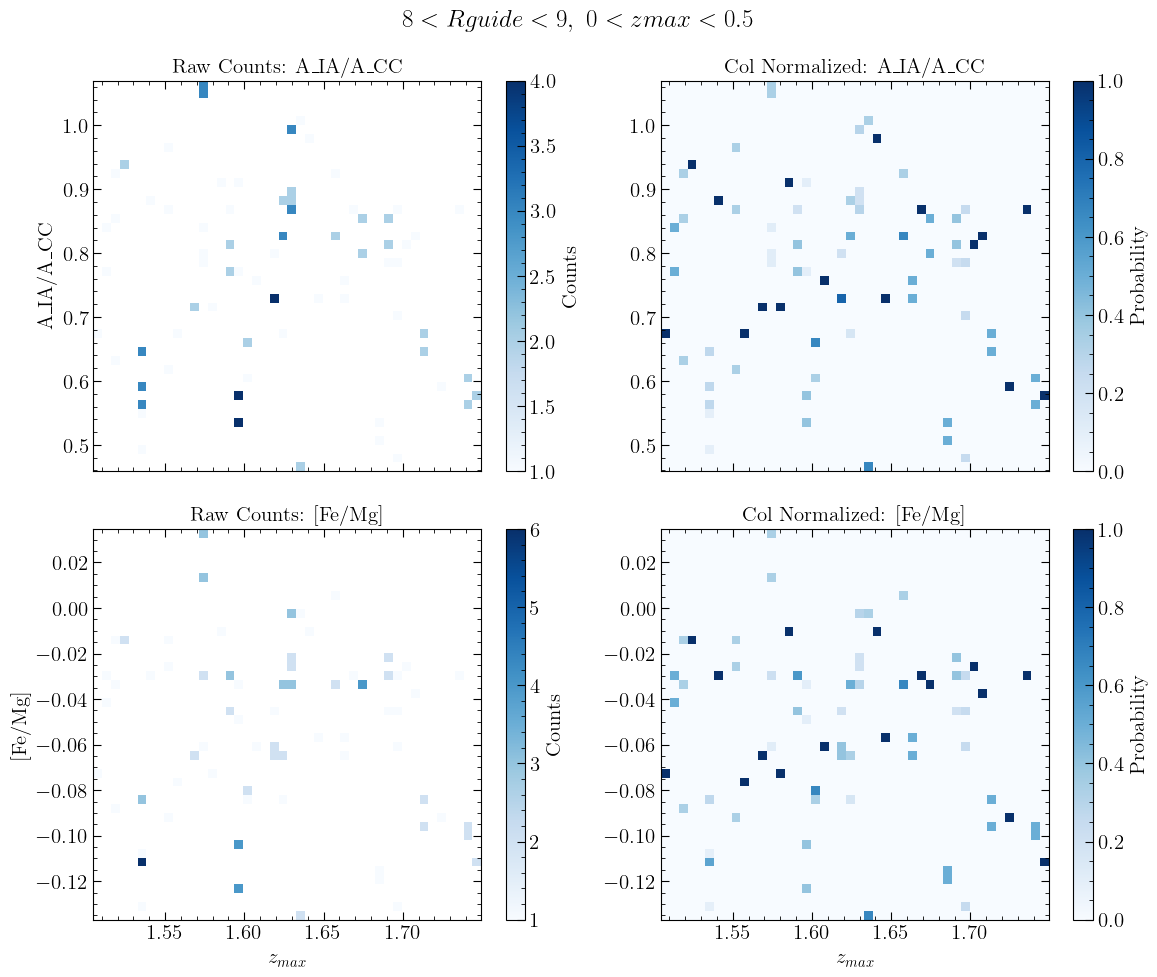

In [14]:
# Setup
n_bins = 45
bin_plot = df[df['zmax_bin'] == 6]
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='Blues')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$8 < R guide < 9, \ 0 < zmax < 0.5 $")
plt.tight_layout()
#plt.savefig('plots/binned_on_met/bin_8_2d_mask1_zmax_large.png', dpi=300)
plt.show()

In [15]:
adrian_df

,APOGEE_ID,E,R_guide,ecc,r_apo,r_per,z_max
0,2M00000002+7417074,-123176.079792,8.981668,0.102972,10.072937,8.192143,0.542263
1,2M00000032+5737103,-124466.032098,8.898811,0.031460,9.187060,8.626634,0.042505
2,2M00000035-7323394,-84000.987389,8.056419,0.563092,33.797902,9.447039,17.557652
3,2M00000068+5710233,-124673.569406,8.748110,0.045083,9.260744,8.461756,0.657589
4,2M00000103+1525513,-125511.573984,8.644169,0.065171,9.278054,8.142727,0.338254
...,...,...,...,...,...,...,...
554733,AP18341149-2302059,-198337.315101,0.882543,0.665774,2.980966,0.598111,0.624067
554734,AP18360488-2407575,-130322.579590,3.792200,0.601156,11.882757,2.959967,3.747784
554735,AP18362085-2354401,-129865.574263,4.370269,0.581286,11.929685,3.158902,3.008016
554736,AP18374668-2351038,-133578.635154,4.301855,0.538474,10.820843,3.246136,2.889714


In [16]:
bin_edges

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])